In [31]:
import os
import time
import shutil
from datetime import datetime
from PIL import Image
from IPython.display import display, Image as IPImage

# Google Generative AI components
import google.generativeai as genai

# --- CONFIGURATION ---
KEY_FILE = "gemini_key.txt"
BASE_DIR = "questionnaire_icons"
RAW_DIR = os.path.join(BASE_DIR, "raw")
OLD_IMAGE_DIR = os.path.join(BASE_DIR, "old_images")
SKIP_EXISTING = False 
RPM_LIMIT = 10        
SLEEP_TIME = 60 / RPM_LIMIT

BG_COL = 102

os.makedirs(BASE_DIR, exist_ok=True)
os.makedirs(RAW_DIR, exist_ok=True)
os.makedirs(OLD_IMAGE_DIR, exist_ok=True)

with open(KEY_FILE, "r") as f:
    api_key = f.read().strip()

genai.configure(api_key=api_key)
# Ensure the model matches what is available in your GCP console
model = genai.GenerativeModel('gemini-2.5-flash-image') 
print("Setup complete. Directories created and API initialized.")

Setup complete. Directories created and API initialized.


In [ ]:
def apply_grey_processing(raw_filepath, final_filepath, bg_color=(BG_COL, BG_COL, BG_COL)):
    """
    Applies the procedural grey background to the B&W raw generation.
    Saves as a flat JPG with no rounded corners.
    """
    # Raw is prompted to be a black background with a white silhouette
    raw_img = Image.open(raw_filepath).convert("L")
    
    # Solid background and solid white icon layers
    bg_layer = Image.new("RGB", raw_img.size, bg_color)
    icon_layer = Image.new("RGB", raw_img.size, (255, 255, 255))
    
    # Composite using raw_img as the alpha mask. 
    # White areas of raw_img take from icon_layer; black areas take from bg_layer.
    final_img = Image.composite(icon_layer, bg_layer, raw_img)
    final_img.save(final_filepath, "JPEG", quality=95)

def generate_icon(filename, subject, variant_suffix="", skip_existing=True):
    full_name = f"{filename}{variant_suffix}"
    raw_filepath = os.path.join(RAW_DIR, f"{full_name}_raw.png")
    final_filepath = os.path.join(BASE_DIR, f"{full_name}.jpg")
    
    if os.path.exists(final_filepath):
        if skip_existing:
            return None
        else:
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            shutil.move(final_filepath, os.path.join(OLD_IMAGE_DIR, f"{timestamp}_{full_name}.jpg"))
            if os.path.exists(raw_filepath):
                shutil.move(raw_filepath, os.path.join(OLD_IMAGE_DIR, f"{timestamp}_{full_name}_raw.png"))

    prompt = (f"A solid white silhouette, centered, pure black background, "
              f"minimalist flat vector icon, no fine lines, high contrast of this:"
              f"'{subject}'"
              f"No text, no shading. Make sure the image takes up most of the space. Do not cluster the content in the centre of the image only.")

    try:
        response = model.generate_content(prompt, generation_config={"response_modalities": ["IMAGE"]})
        for part in response.candidates[0].content.parts:
            if hasattr(part, 'inline_data') and part.inline_data.data:
                # Save raw B&W PNG
                with open(raw_filepath, "wb") as f:
                    f.write(part.inline_data.data)
                
                # Apply procedural styling
                apply_grey_processing(raw_filepath, final_filepath)
                return final_filepath
    except Exception as e:
        print(f"API Error for {full_name}: {e}")
    
    return None

In [53]:
## {"filename": "", "prompt": ""},

icons_to_generate = [
    ## MODALITIES
    # {"filename": "visual", "prompt": "A simple open eye"},
    # {"filename": "auditory", "prompt": "A minimalist ear profile"},
    # {"filename": "smell", "prompt": "A stylized nose profile"},
    # {"filename": "time", "prompt": "a simple clock face"},
    # {"filename": "taste", "prompt": "A simple tongue profile"},
    # {"filename": "physicalSensations", "prompt": "a simple icon of a hand"},
    # {"filename": "sense of body", "prompt": "a simple human figure standing upright in the style of the signs on restroom doors"},
    # {"filename": "self", "prompt": "a simple icon of an empty mirror"},
    
    ## VISUAL 
    # {"filename": "geometric", "prompt": "an image icon representing geometry, an image showing scattered shapes and lines across the image"},
    # {"filename": "semantic", "prompt": " a landscape with a tree and a person standing"},
    # {"filename": "distortions", "prompt": "an image representing the idea of a spatial transform distortion via a swirling effect. Show a clear icon of a human figure like the sign on a restroom but the figure has been swirl distorted in the centre, such that the figure is recognisable but the distortion is very clear. make the image look like a simple mathematical warp was applied over the icon, not a drawing of a swirl"},
    # {"filename": "phosphenes", "prompt": "an image icon representing visual snow, or visual noise lots of dots across the image. Do not put the dots in a box, spread them out across the image"},
    # {"filename": "symbols", "prompt": "an icon showing a scattering of a few random symbols in different styles, including a letter, a number, a musical note, and an abstract symbol which looks plausibly like a real symbol but is from no real language. all spread out across the image, scattered symbols. They should be bold and large, taking up the whole space of the imaage"},
    
    # ## DIRECTIONS
    # {"filename": "directionalMovement", "prompt": "arrows pointing all in one diagonal direction"},
    # {"filename": "rotational movement", "prompt": "arrows pointing arounnd in a circle"},
    # {"filename": "zooming movement", "prompt": "arrows pointing inwards and outwards towards the centre of the image"},
    # {"filename": "chaotic movement", "prompt": "arrows pointing in various directions randomly"},
    
    # ## AUDITORY
    # {"filename": "ringing", "prompt": "a simple icon for rining sound, one dot with ringing semicirles eminating from it"},
    # {"filename": "music", "prompt": "musical notes"},
    # {"filename": "buzzing", "prompt": "a simple icon for buzzing sound, one dot with buzzing zigzag lines eminating from it"},
    # {"filename": "white noise", "prompt": "a simple icon for white noise, a dot with lots of small dots eminating from it"},
    # {"filename": "voices", "prompt": "a simple icon for voices, a dot with small speech bubbles eminating from it"},


    # SYMBOLS
    {"filename": "text", "prompt": "a scattering of random letters spead evenly across the image. Do NOT cluster the letters in the centre, spread them out across the image. Its a random array of letters spread EVENLY and randomly across the image, not clustered in the centre"},
    #{"filename": "numbers", "prompt": "a scattering of random numbers spread evenly across the image. Do NOT cluster the numbers in the centre, spread them out across the image"},
    #{"filename": "musical", "prompt": "a scattering of random musical notations spread evenly across the image. Do NOT cluster the notations in the centre, spread them out across the image"},
    #{"filename": "unrecognized", "prompt": "a scattering of random abstract symbols which look plausibly like real symbols but are from no real language, spread evenly across the image. Do NOT cluster the symbols in the centre, spread them out across the image"},

]

Starting generation for 1 icons...
Generated: questionnaire_icons\text.jpg


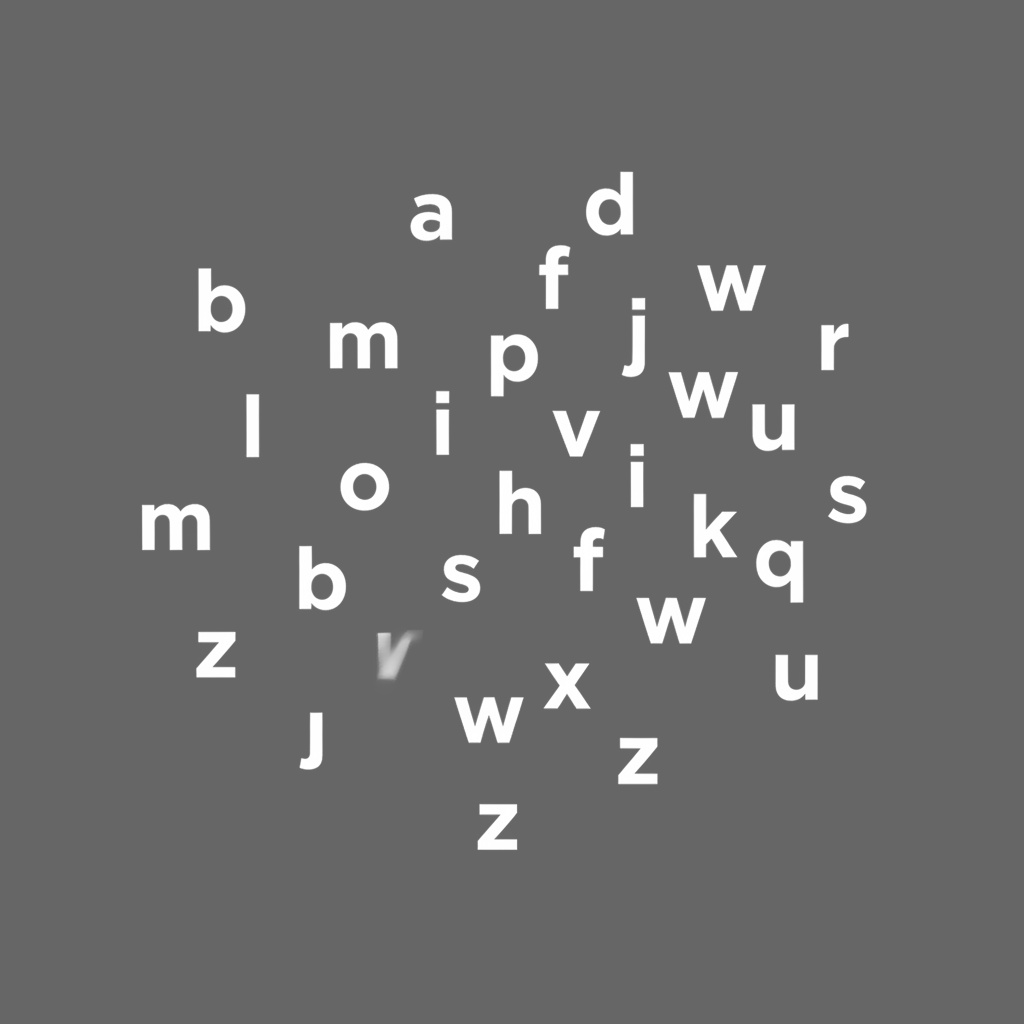

Initial processing complete.


In [51]:
print(f"Starting generation for {len(icons_to_generate)} icons...")

for item in icons_to_generate:
    filename = item["filename"]
    prompt = item["prompt"]
    
    path = generate_icon(filename, prompt, skip_existing=SKIP_EXISTING)
    
    if path:
        print(f"Generated: {path}")
        display(IPImage(filename=path, width=150))
        #time.sleep(SLEEP_TIME)

print("Initial processing complete.")

## redos and recolours


Starting variation generation...
Generating variation _1 for: taste


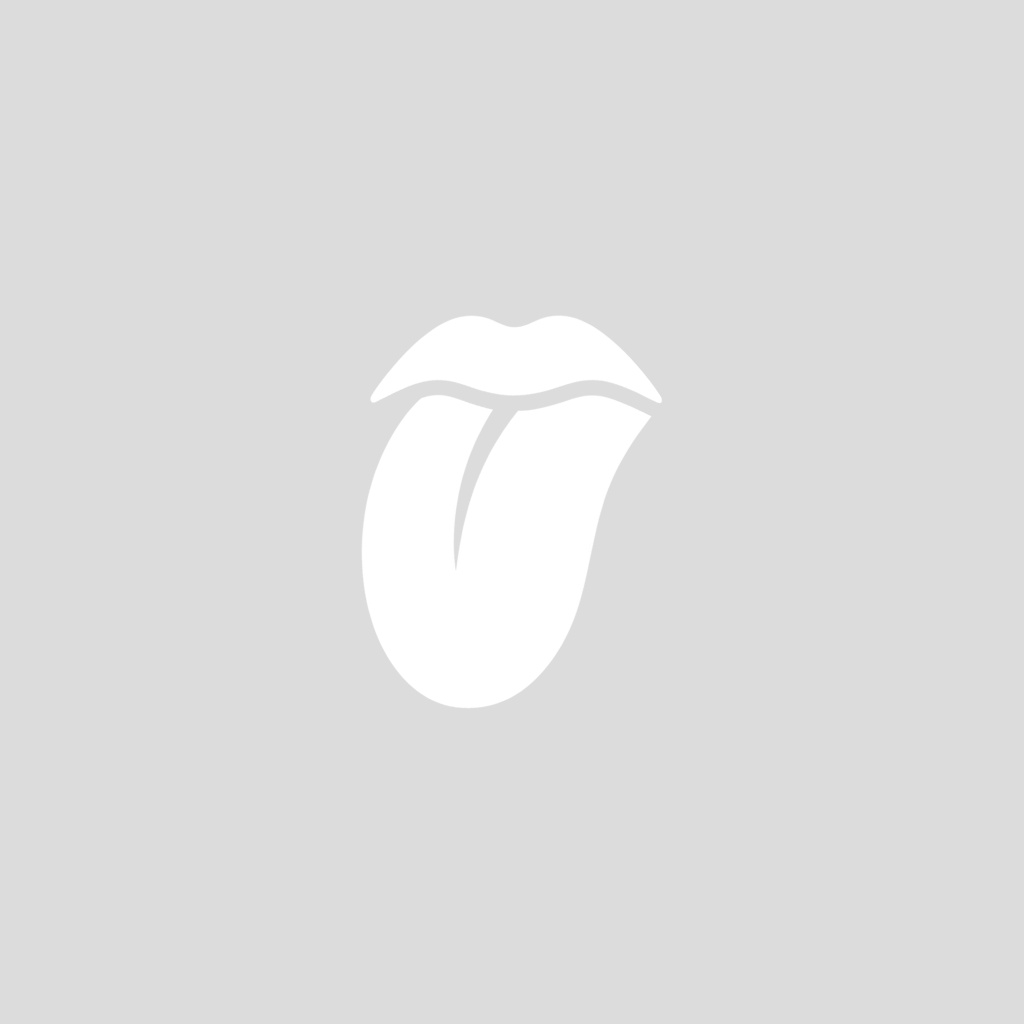

Generating variation _2 for: taste


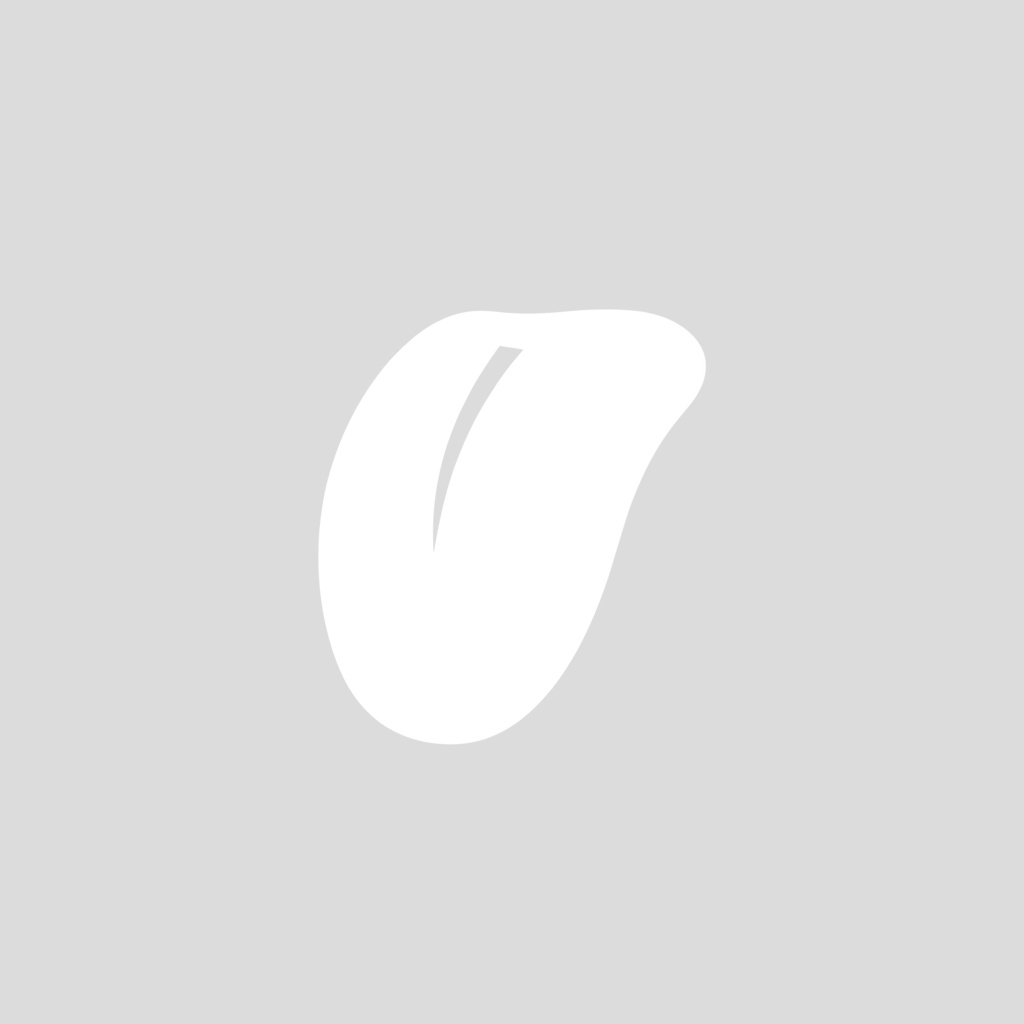

Generating variation _3 for: taste


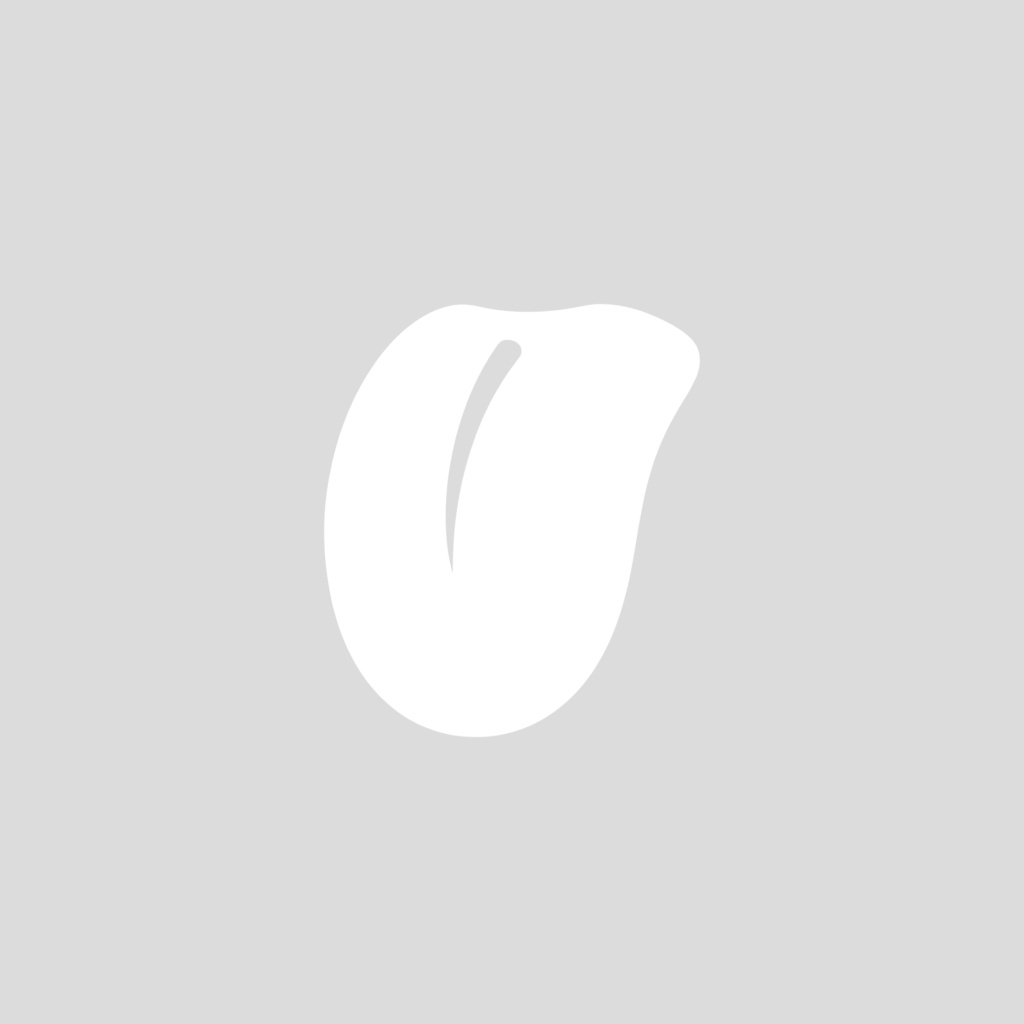

Variations complete.


In [9]:
# Specify icons to regenerate and how many variations you want
icons_to_revisit = [
    {"filename": "taste", "prompt": "A simple tongue with nothing else, no lips or mouth. Do NOT generate an image of a mouth", "variations": 3},
]

print("Starting variation generation...")
for item in icons_to_revisit:
    filename = item["filename"]
    prompt = item["prompt"]
    variations = item.get("variations", 1)
    
    for i in range(1, variations + 1):
        suffix = f"_{i}"
        print(f"Generating variation {suffix} for: {filename}")
        
        # skip_existing=False forces a fresh generation and archives existing versions with this suffix
        path = generate_icon(filename, prompt, variant_suffix=suffix, skip_existing=False)
        
        if path:
            display(IPImage(filename=path, width=150))
            time.sleep(SLEEP_TIME)
            
print("Variations complete.")

In [ ]:
# Run this cell to test different shades of grey. 
# It uses the saved raw files, allowing instant changes without hitting the API.

NEW_BG_COLOR = (BG_COL, BG_COL, BG_COL) # Adjust this RGB tuple

raw_files = [f for f in os.listdir(RAW_DIR) if f.endswith("_raw.png")]
print(f"Found {len(raw_files)} raw files to re-process.")

for raw_filename in raw_files:
    base_name = raw_filename.replace("_raw.png", "")
    final_filename = f"{base_name}.jpg"
    
    raw_path = os.path.join(RAW_DIR, raw_filename)
    final_path = os.path.join(BASE_DIR, final_filename)
    
    apply_grey_processing(raw_path, final_path, bg_color=NEW_BG_COLOR)

print("All images procedurally recolored.")

Found 29 raw files to re-process.
All images procedurally recolored.


Starting procedural cropping...
Successfully cropped and updated: text (200px removed from edges)


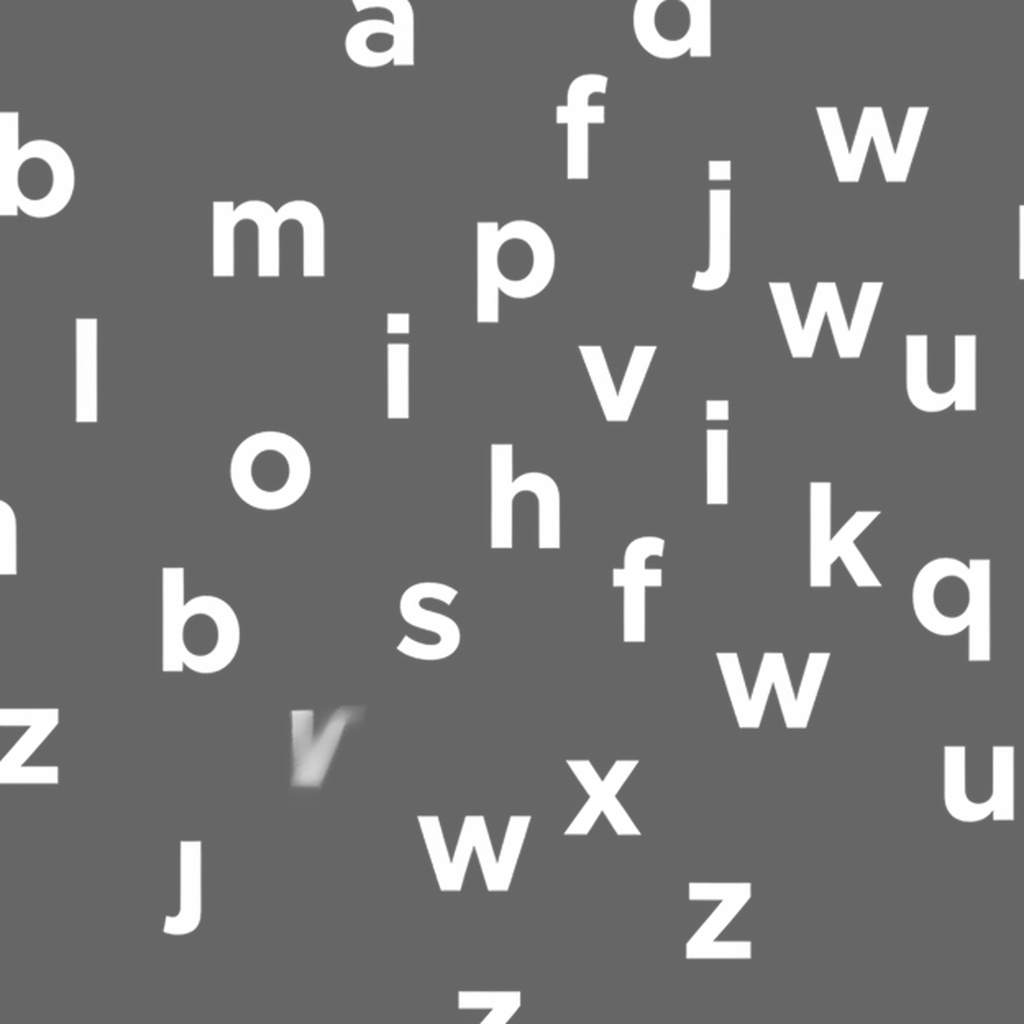

Cropping process complete.


In [55]:
def crop_and_reprocess_icon(filename, crop_pixels, bg_color=(BG_COL, BG_COL, BG_COL)):
    """
    Takes a raw B&W file, crops 'crop_pixels' from all edges, resizes it back
    to original dimensions to 'zoom in' the icon, and applies the grey processing.
    """
    raw_filename = f"{filename}_raw.png"
    final_filename = f"{filename}.jpg"
    
    raw_path = os.path.join(RAW_DIR, raw_filename)
    final_path = os.path.join(BASE_DIR, final_filename)
    
    if not os.path.exists(raw_path):
        print(f"Error: Raw file not found for '{filename}' at {raw_path}")
        return False
        
    # 1. Load raw image
    raw_img = Image.open(raw_path).convert("L")
    original_size = raw_img.size
    
    # 2. Define cropping box (left, upper, right, lower)
    # This crops equally from all 4 sides
    box = (
        crop_pixels, 
        crop_pixels, 
        original_size[0] - crop_pixels, 
        original_size[1] - crop_pixels
    )
    
    # Validate crop size
    if box[2] <= box[0] or box[3] <= box[1]:
        print(f"Error: Crop amount ({crop_pixels}px) is too large for image size {original_size}")
        return False
        
    cropped_raw = raw_img.crop(box)
    
    # 3. Resize back to original dimensions to preserve layout integrity
    resized_raw = cropped_raw.resize(original_size, Image.Resampling.LANCZOS)
    
    # 4. Apply standard procedural grey background
    bg_layer = Image.new("RGB", original_size, bg_color)
    icon_layer = Image.new("RGB", original_size, (255, 255, 255))
    
    final_img = Image.composite(icon_layer, bg_layer, resized_raw)
    final_img.save(final_path, "JPEG", quality=95)
    return True

# --- CONFIGURATION FOR CROPPING ---
# Specify the filename (without extensions or '_raw') and the number of pixels to slice off the edges.
# Higher pixel values mean a tighter crop (closer zoom).
icons_to_crop = [
    #{"filename": "phosphenes", "crop_pixels": 300},
    #{"filename": "semantic", "crop_pixels": 300},
    {"filename": "text", "crop_pixels": 200},
]

# Use the same color shade defined in your Cell 6 configurations
CURRENT_BG_COLOR = (BG_COL, BG_COL, BG_COL) 

print("Starting procedural cropping...")
for item in icons_to_crop:
    name = item["filename"]
    pixels = item["crop_pixels"]
    
    success = crop_and_reprocess_icon(name, pixels, bg_color=CURRENT_BG_COLOR)
    if success:
        print(f"Successfully cropped and updated: {name} ({pixels}px removed from edges)")
        display(IPImage(filename=os.path.join(BASE_DIR, f"{name}.jpg"), width=150))

print("Cropping process complete.")